In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import kpss
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

In [15]:
df = pd.read_csv('../dataset/Walmart.csv')

# Convert to datetime
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df.head()

# Group by Date and aggregate (e.g., sum for Weekly_Sales)
df = df.groupby('Date').agg({
  'Weekly_Sales': 'sum',
  'Holiday_Flag': 'max',
  'Temperature': 'mean',
  'Fuel_Price': 'mean',
  'CPI': 'mean',
  'Unemployment': 'mean'
}).reset_index()

df.head()

# Graph
#result = seasonal_decompose(df['FEDFUNDS'], model ='multiplicative')
#result.plot()

# data["detrended"] = sm.OLS(data["FEDFUNDS"], sm.add_constant(range(len(data)))).fit().resid
# data["differenced"] = data["FEDFUNDS"].diff()

,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,2010-02-05,49750740.50,0,34.037333,2.717844,167.730885,8.619311
1,2010-02-12,48336677.63,1,34.151333,2.694022,167.825608,8.619311
2,2010-02-19,48276993.78,0,37.719778,2.672067,167.871686,8.619311
3,2010-02-26,43968571.13,0,39.243556,2.683933,167.909657,8.619311
4,2010-03-05,46871470.30,0,42.917333,2.731200,167.947628,8.619311


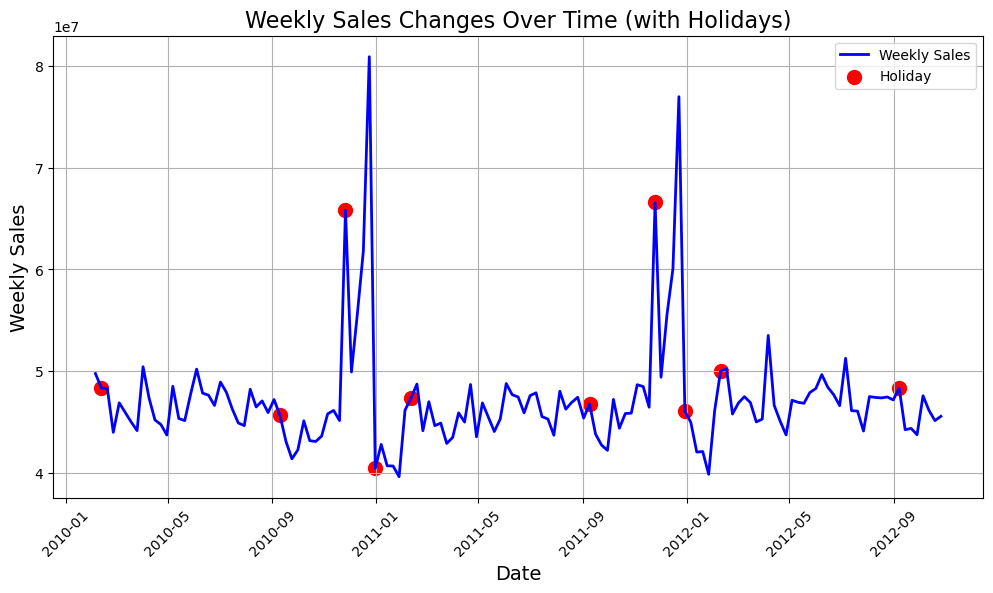

In [16]:
# Plot Weekly Sales over Time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Weekly_Sales'], color='blue', linewidth=2, label='Weekly Sales')

# Highlight Holidays
holiday_dates = df[df['Holiday_Flag'] == 1]  # Filter rows where Holiday_Flag is 1
plt.scatter(holiday_dates['Date'], holiday_dates['Weekly_Sales'], color='red', marker='o', s=100, label='Holiday')

# Add titles and labels
plt.title('Weekly Sales Changes Over Time (with Holidays)', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Weekly Sales', fontsize=14)
plt.grid(True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Show legend
plt.legend()

# Show the plot
plt.show()

In [17]:
# ADF Test
result_test = adfuller(df['Weekly_Sales'])

print(f"ADF Statistic: {result_test[0]}")
print(f"P-value: {result_test[1]}")
print(f"Critical Values: {result_test[4]}")

if result_test[1] < 0.05:
  print("Reject H0: Data is stationary")
else:
  print("Fail to reject H0: Data is non-stationary")

ADF Statistic: -5.90829795718633
P-value: 2.6759791589860825e-07
Critical Values: {'1%': np.float64(-3.47864788917503), '5%': np.float64(-2.882721765644168), '10%': np.float64(-2.578065326612056)}
Reject H0: Data is stationary


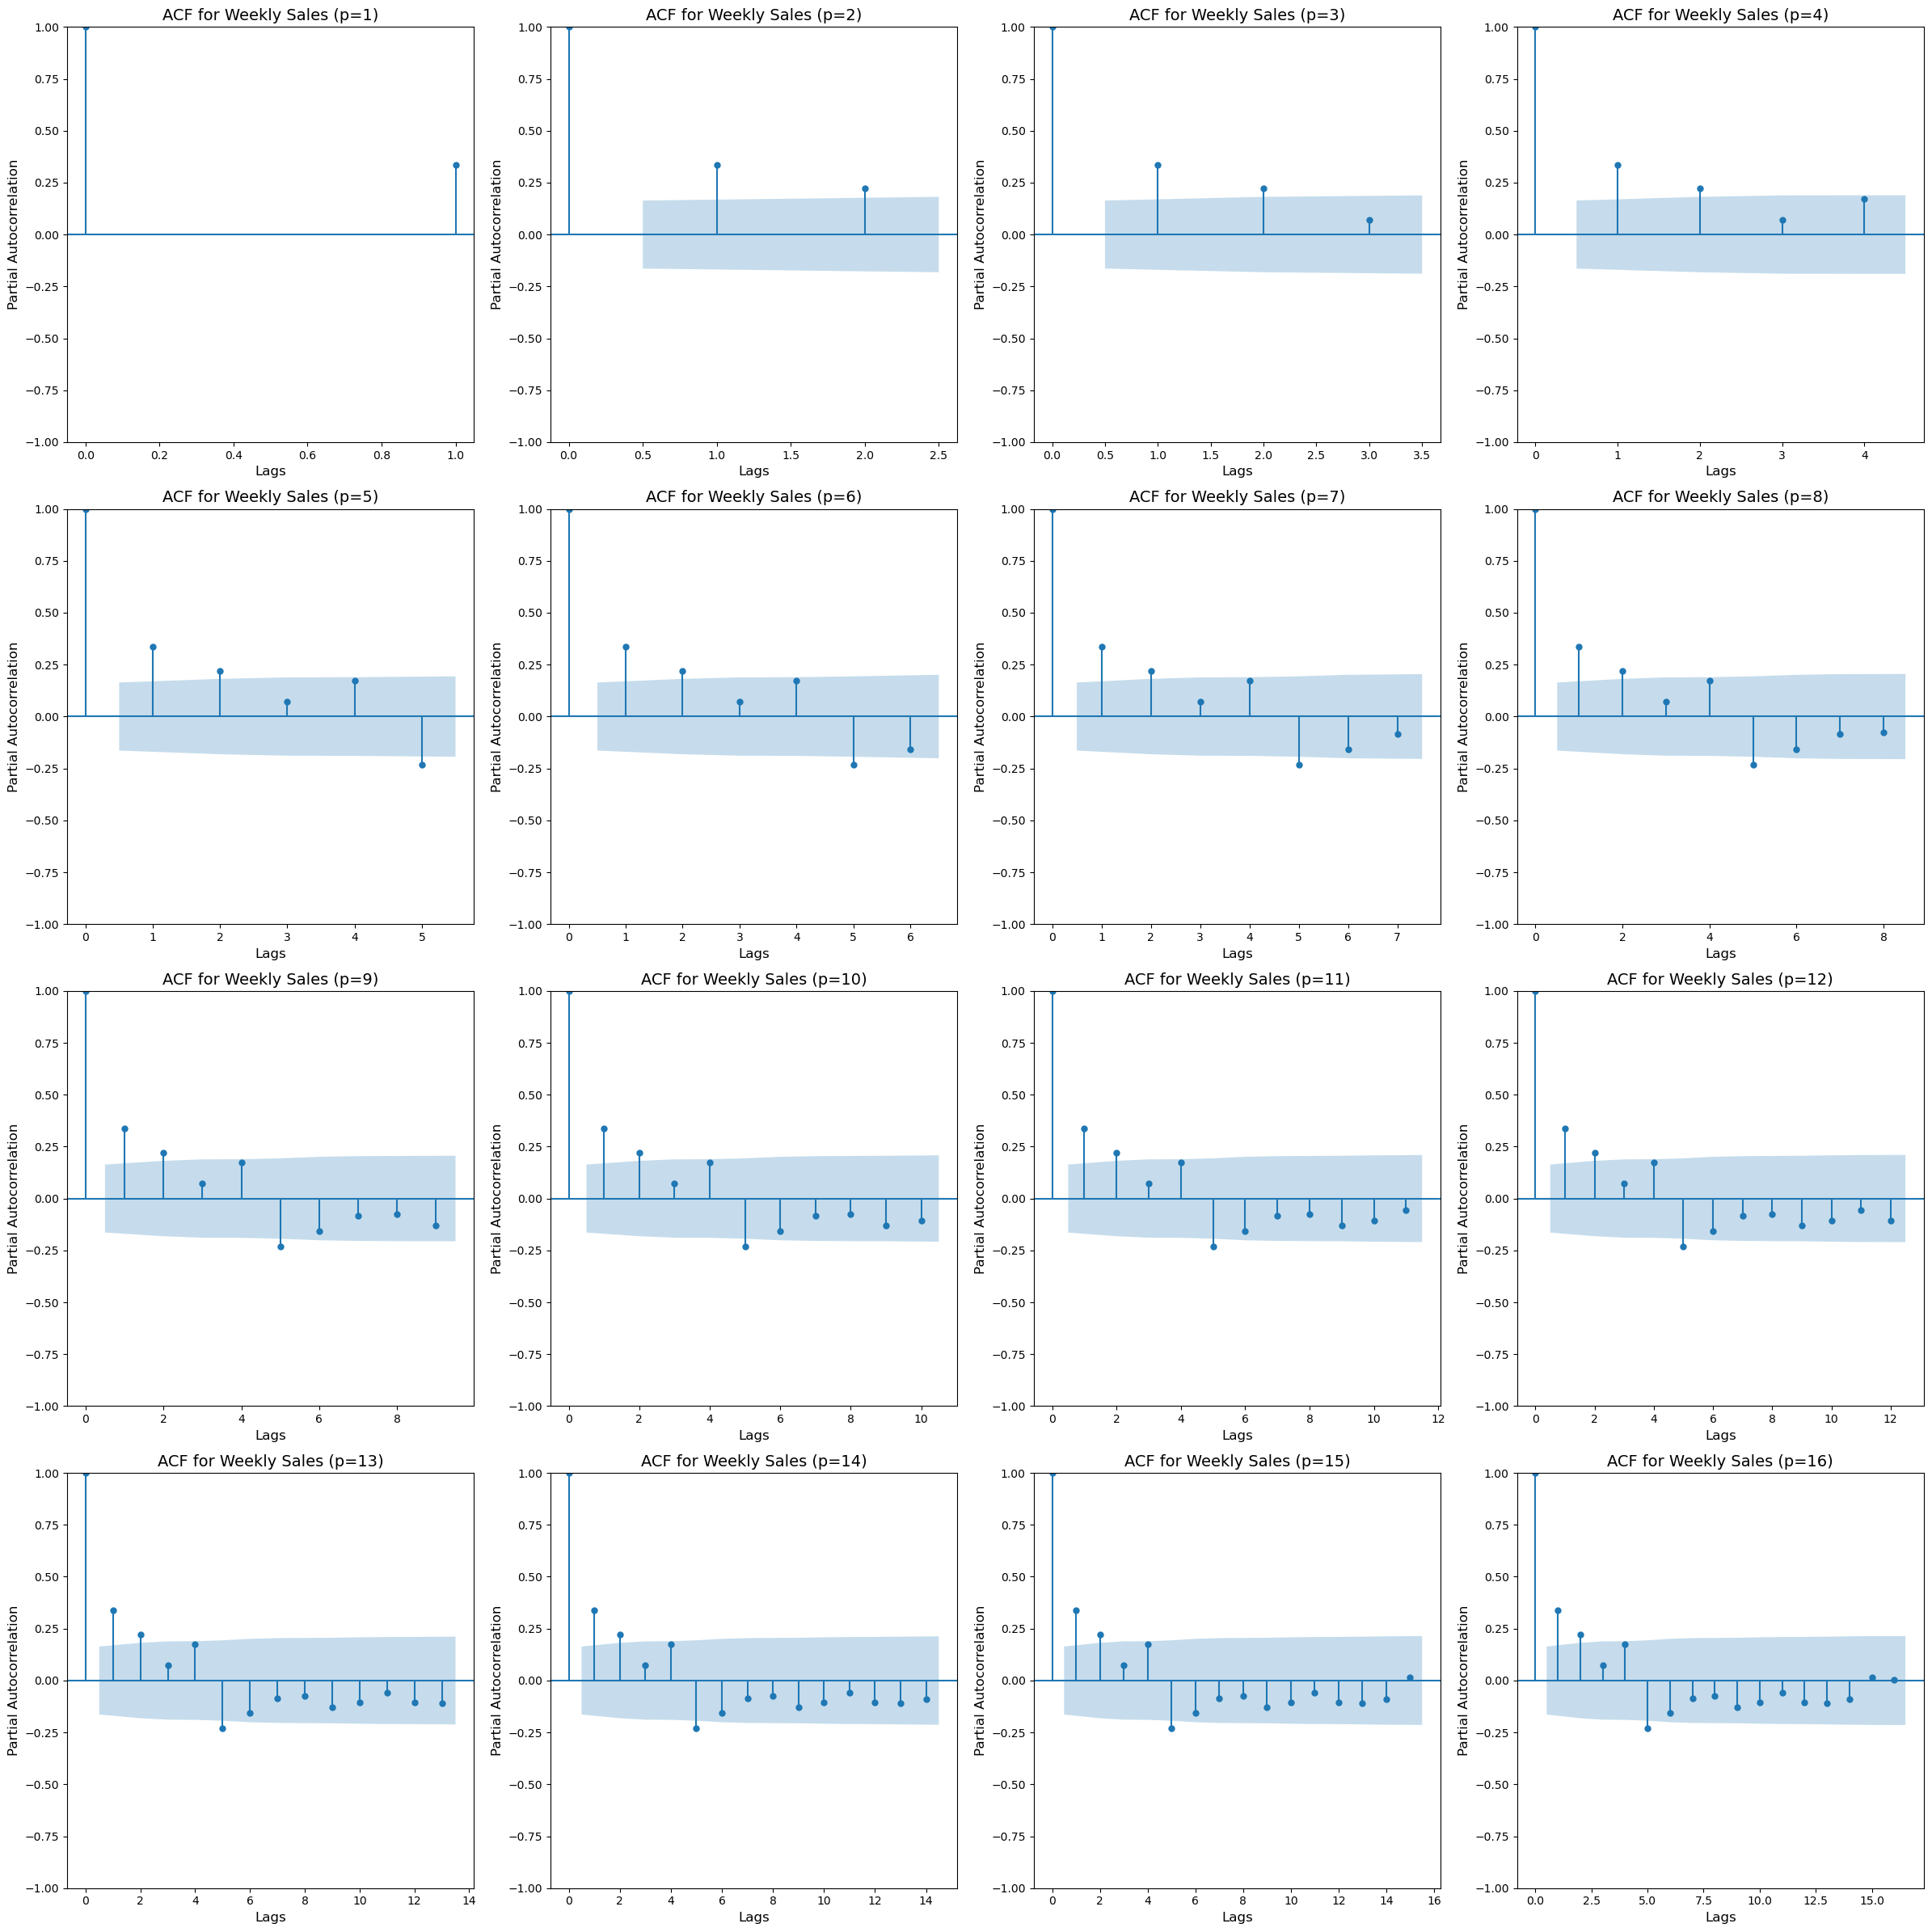

In [18]:
# Plot ACF for 'Weekly_Sales' for different values of p (lags)
fig, axes = plt.subplots(4, 4, figsize=(24, 24))  # Create subplots for multiple values of p
axes = axes.flatten()

# Different values of p (lags)
p_values = range(1, 17)

for i, p in enumerate(p_values):
  plot_acf(df['Weekly_Sales'], lags=p, ax=axes[i])
  axes[i].set_title(f'ACF for Weekly Sales (p={p})', fontsize=14)
  axes[i].set_xlabel('Lags', fontsize=12)
  axes[i].set_ylabel('Partial Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()

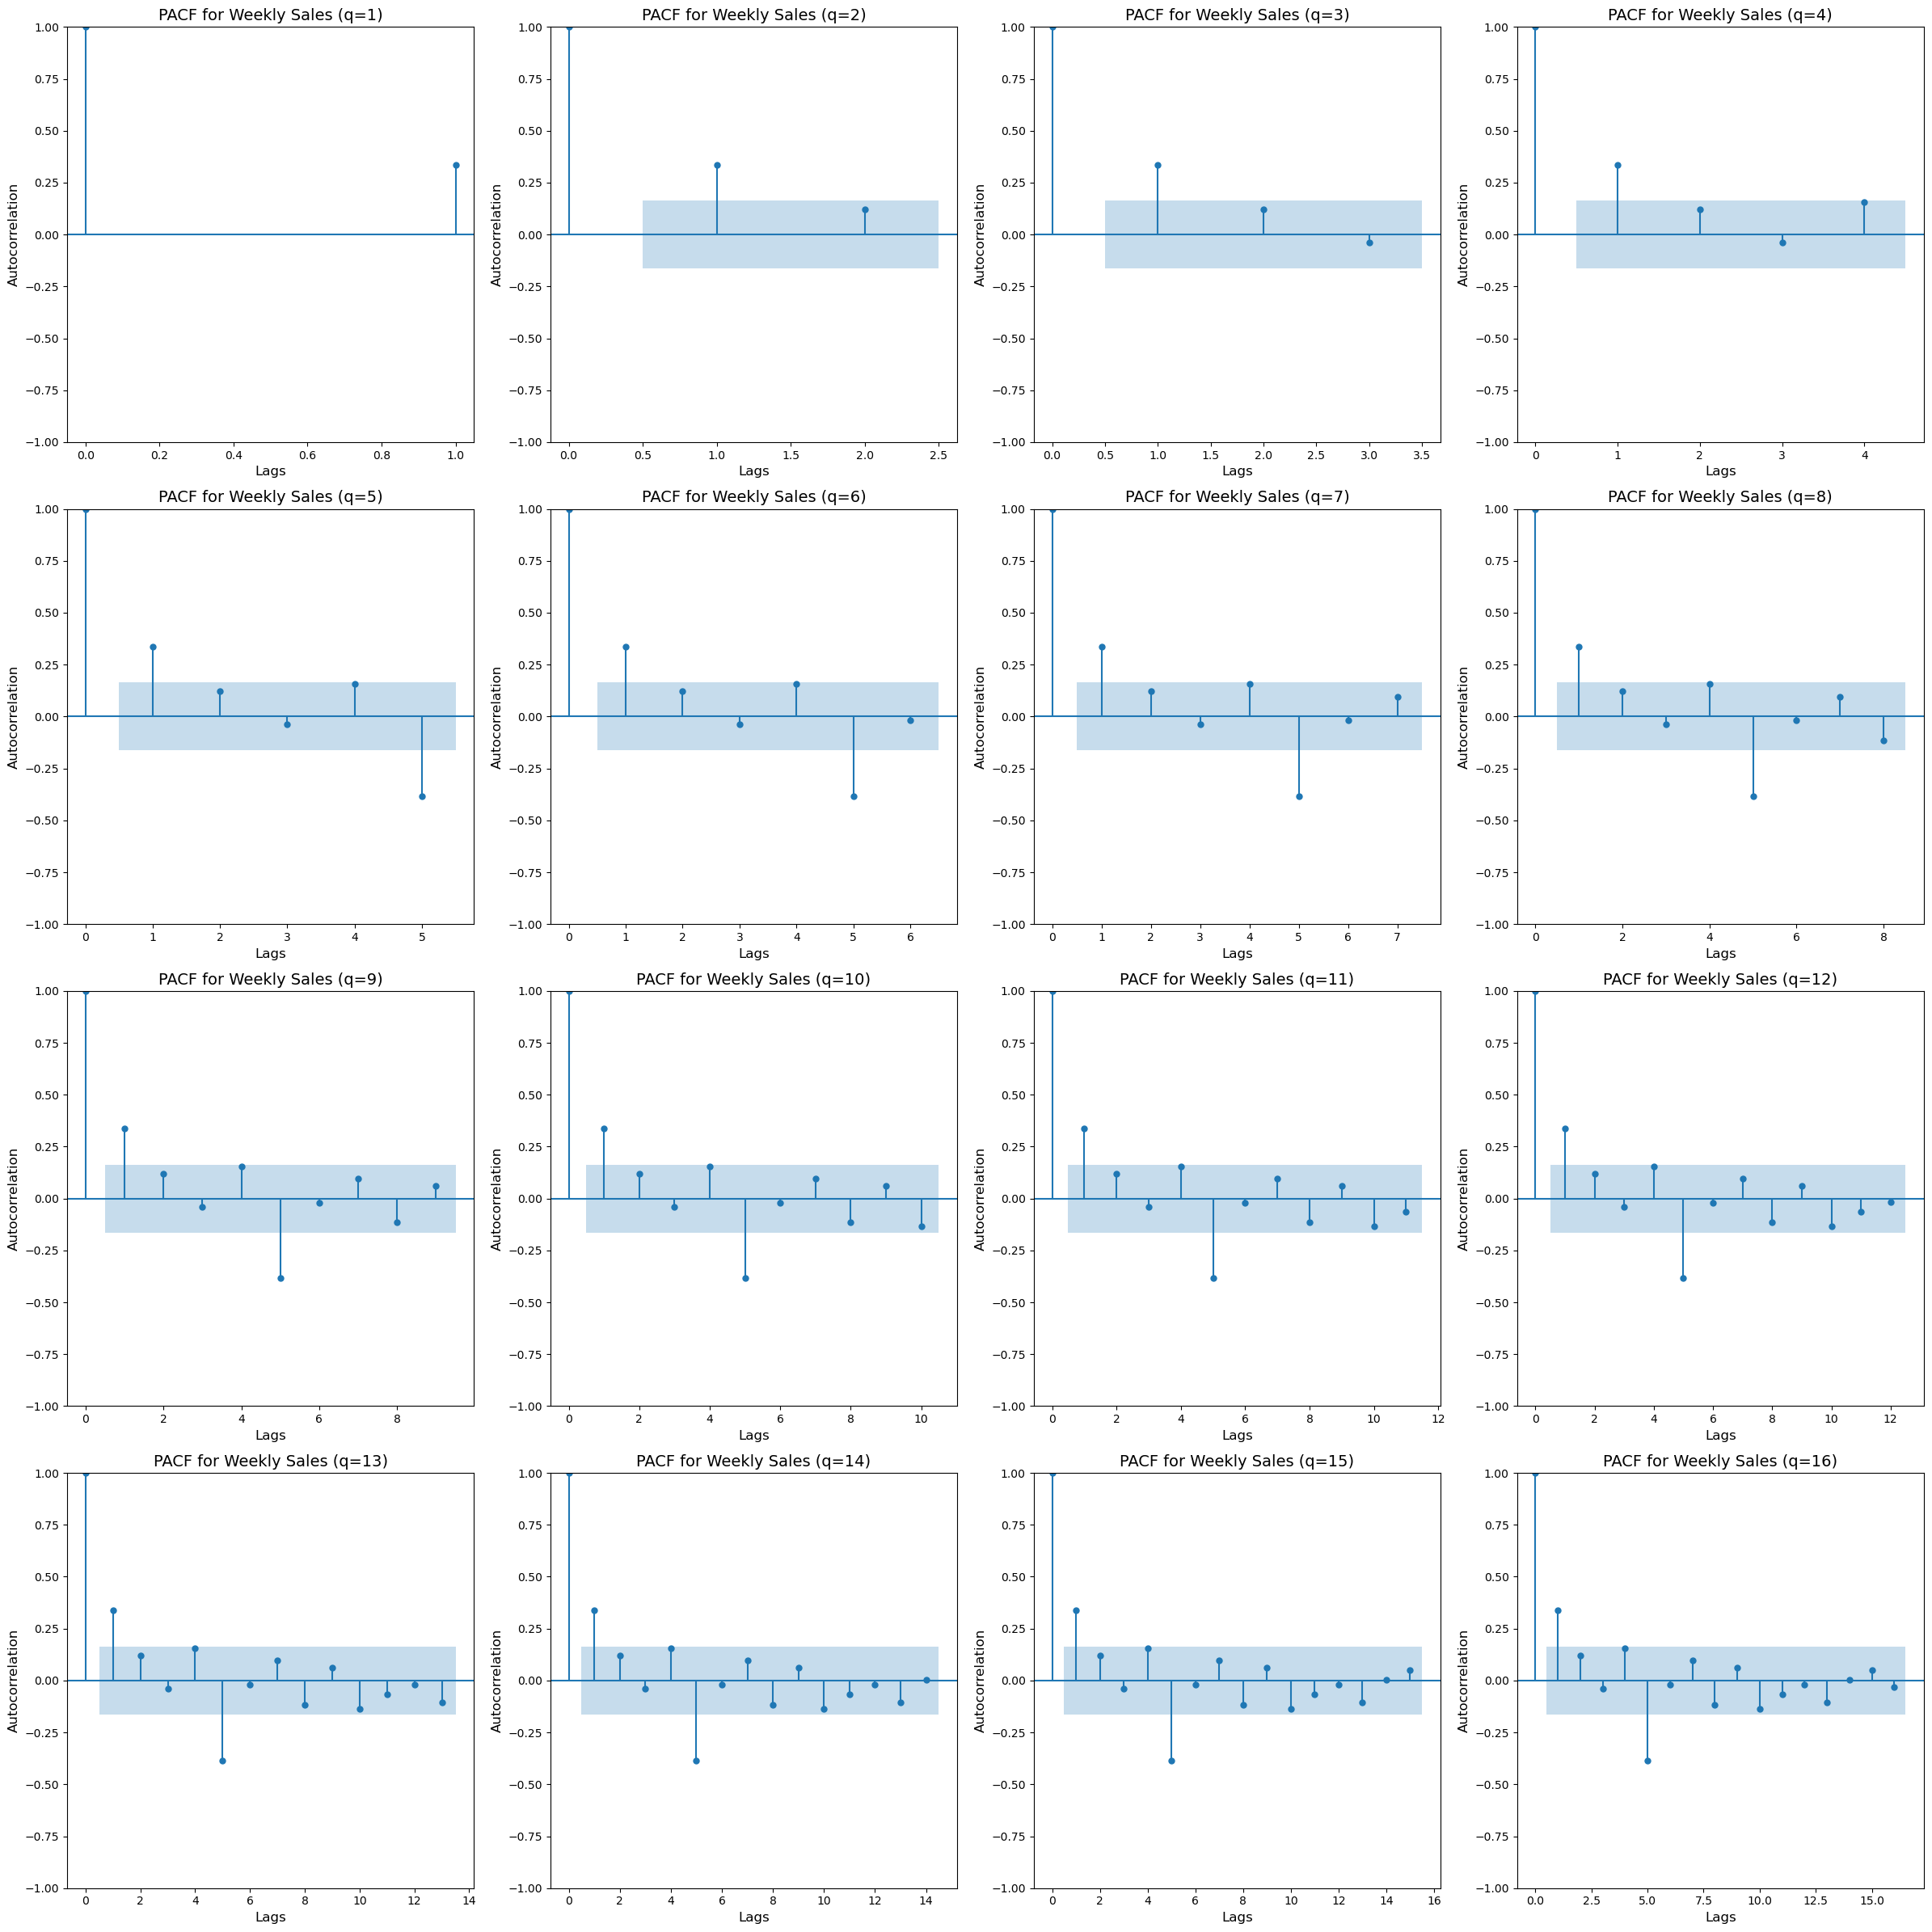

In [19]:
# Plot PACF for 'Weekly_Sales' for different values of q (lags)
fig, axes = plt.subplots(4, 4, figsize=(24, 24))  # Create subplots for multiple values of q
axes = axes.flatten()

# Different values of q (lags)
q_values = range(1, 17)

for i, q in enumerate(q_values):
  plot_pacf(df['Weekly_Sales'], lags=q, ax=axes[i])
  axes[i].set_title(f'PACF for Weekly Sales (q={q})', fontsize=14)
  axes[i].set_xlabel('Lags', fontsize=12)
  axes[i].set_ylabel('Autocorrelation', fontsize=12)

plt.tight_layout()
plt.show()


From our charts, p = q = 3. From our ADF test, d = 0